# Mini-Projet : Système intelligent d’analyse des ventes

Etapes
- Compréhension du problème (Business Understanding)
- Analyse exploratoire des données (EDA)
- Prétraitement des données
- Modélisation Machine Learning
- Évaluation du modèle
- Architecture du système
- Déploiement

# Partie 1 : Analyse du problème

### 1. Identifier les objectifs du système

Le système doit :
- analyser les ventes
- prévoir les ventes futures
- détecter les fraudes / anomalies
- être déployé sur Internet

Compréhension du problème (Business Understanding)

**Objectifs**

Le système doit :
- analyser les ventes
- prévoir les ventes futures
- détecter les fraudes / anomalies
- être déployé sur Internet

Questions à répondre
- Quelles variables influencent les ventes ?
- Quel indicateur veut-on prédire ?

Exemple : Sales=Quantity×UnitPrice

Donc la variable cible peut être : Sales

## Partie 2 : Analyse des données

In [84]:
# Import des librairies
from module.utils import *
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

2) Analyse exploratoire des données

In [85]:
# Chargement
df = load_data("data/online_retail.csv")
df.shape

(541909, 8)

In [86]:
# 5 premiers lignes
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [87]:
# Structure des données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


Variables les plus importantes

- Quantity : quantité vendue
- UnitPrice : prix unitaire
- InvoiceDate : permet d’analyser les tendances temporelles (jour, mois, saison)
- CustomerID : comportement des clients et détecter les fraudes
- Country :  permet d’identifier les zones géographiques
- StockCode / Description : influence liée au type de produit

In [88]:
# Stats de bases
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [89]:
# Vérifier les valeurs manquantes
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [90]:
# Données dupliquées
df.duplicated().sum()

np.int64(5268)

In [91]:
# Suppression des NA et données dupliquées
df_copy = df.copy()
df = clean_data(df_copy)

create_target(df) # Valeur cible

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60


In [92]:
df.shape

(392692, 9)

**Pourquoi certaines transactions peuvent être anormales ?**

- Fraude : Un client peut effectuer un achat inhabituel : très grande quantité achats répétés en peu de temps
montants anormalement élevés
- Erreurs de saisie

mauvaise quantité entrée

prix mal saisi

facture en double

Les données bruitées doivent être nettoyées avant l’entraînement du modèle.

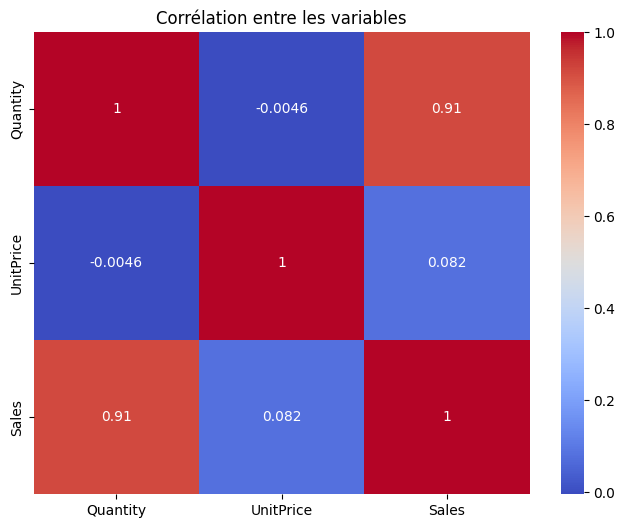

In [93]:
# Corrélation des variables numériques
# Variables numériques
numeric_cols = ['Quantity', 'UnitPrice', 'Sales']

# Matrice de corrélation
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Corrélation entre les variables")
plt.show()

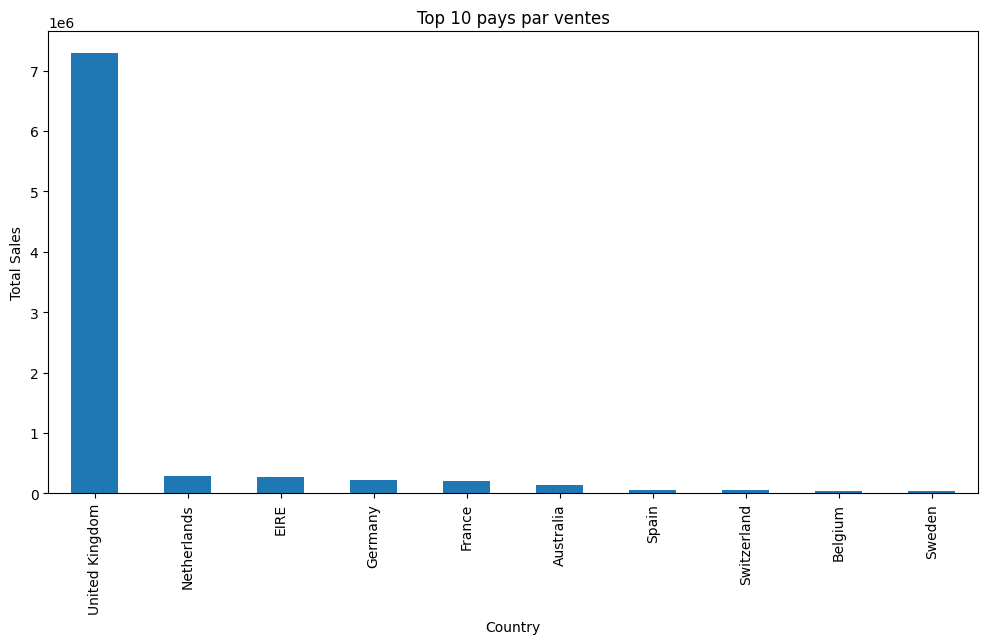

In [94]:
# Analyse par pays
sales_by_country = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sales_by_country.head(10).plot(kind='bar')
plt.title("Top 10 pays par ventes")
plt.ylabel("Total Sales")
plt.show()

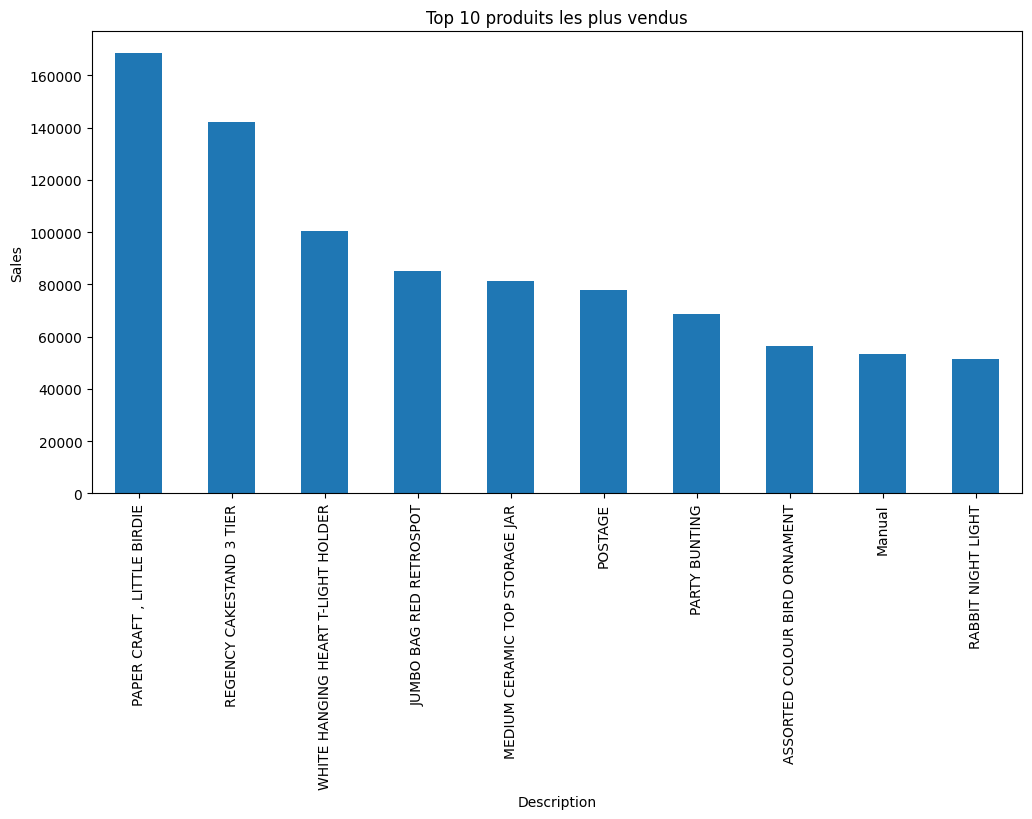

In [95]:
# Analyse par produit
sales_by_product = df.groupby('Description')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sales_by_product.head(10).plot(kind='bar')
plt.title("Top 10 produits les plus vendus")
plt.ylabel("Sales")
plt.show()

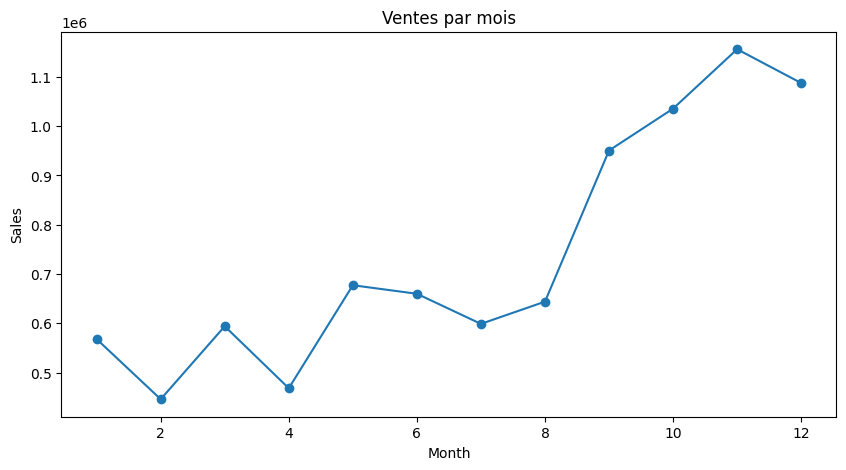

In [96]:
# Analyse temporelle
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Ventes par mois")
plt.ylabel("Sales")
plt.show()

In [97]:
# Suppression des valeurs aberrantes
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

dfa = df[(df['Sales'] >= Q1 - 1.5 * IQR) &
        (df['Sales'] <= Q3 + 1.5 * IQR)]

dfa.shape

(361461, 12)

# Partie 3 : Conception du modèle

3) Prétraitement des données

In [98]:
# Feature engineering
create_time_features(df)

cols = ["Sales", "InvoiceDate", "Month", "Day", "WeekDay"]
df[cols].head()

,Sales,InvoiceDate,Month,Day,WeekDay
0,15.30,2010-12-01 08:26:00,12,1,2
1,20.34,2010-12-01 08:26:00,12,1,2
2,22.00,2010-12-01 08:26:00,12,1,2
3,20.34,2010-12-01 08:26:00,12,1,2
4,20.34,2010-12-01 08:26:00,12,1,2


In [99]:
X_sales, y = prepare_sales_features(df)
X_fraud = prepare_fraud_features(df)

## Choix des modèles

A) Prédiction des ventes

C’est un problème de régression

Modèles recommandés :
- Random Forest
- XGBoost

Raison :
- XGBoost pour la performance
- Random Forest pour la simplicité

In [100]:
seed = 42

# Split
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_sales, y,
    test_size=0.2,
    random_state=seed
)

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fraud,
    y,
    test_size=0.2,
    random_state=seed
)

print("Train shape sale : ", Xs_train.shape)
print("Test shape sale : ", Xs_test.shape)
print("Train shape fraude :", Xf_train.shape)
print("Test shape:", Xf_test.shape)

Train shape sale :  (314153, 6)
Test shape sale :  (78539, 6)
Train shape fraude : (314153, 3)
Test shape: (78539, 3)


In [101]:
# =========================
# Random Forest
# =========================
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=seed,
    n_jobs=-1 # nombre de processeurs (-1 tout)
)

rf_model.fit(Xs_train, ys_train)

rf_pred = rf_model.predict(Xs_test)

rf_metrics  = evaluate_regression(ys_test, rf_pred)
print_metrics(rf_metrics, "Random Forest")


===== RANDOM FOREST =====
RMSE : 426.5400
MAE  : 4.1582
R2   : 0.5039


In [102]:
# =========================
# XGBoost
# =========================
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=seed
)

xgb_model.fit(Xs_train, ys_train)

xgb_pred = xgb_model.predict(Xs_test)
xgb_metrics  = evaluate_regression(ys_test, xgb_pred)
print_metrics(xgb_metrics, "XGBoost")


===== XGBOOST =====
RMSE : 327.4534
MAE  : 3.1634
R2   : 0.7076


### Evaluation

In [103]:
# Comparaison
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rf_metrics['RMSE'], xgb_metrics['RMSE']],
    "MAE": [rf_metrics['MAE'], xgb_metrics['MAE']],
    "R2 Score": [rf_metrics['R2'], xgb_metrics['R2']]
})

results

,Model,RMSE,MAE,R2 Score
0,Random Forest,426.540044,4.158223,0.503939
1,XGBoost,327.453358,3.163403,0.707642


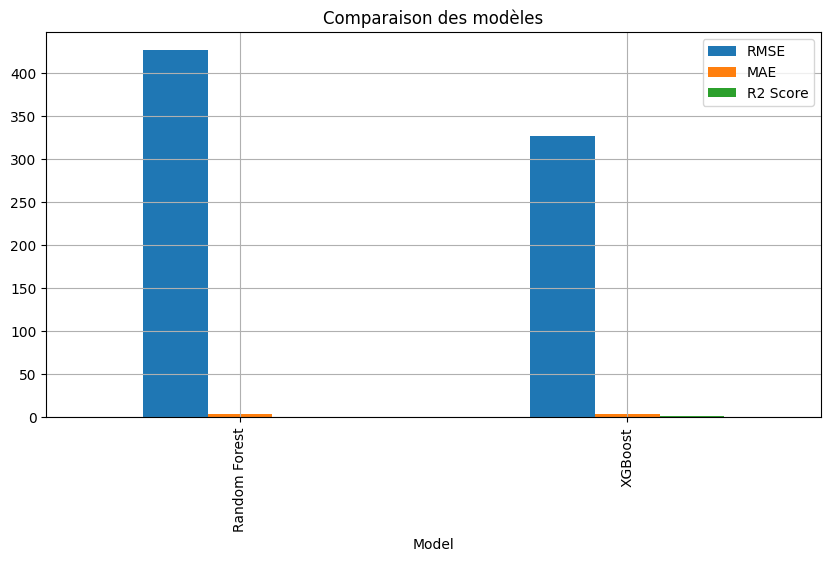

In [104]:
results.plot(
    x="Model",
    y=["RMSE", "MAE", "R2 Score"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparaison des modèles")
plt.grid(True)
plt.show()

- RMSE plus faible → 327.45 < 426.54
- R² plus élevé → 0.70 > 0.50

XGBoost est meilleur.

In [105]:
joblib.dump(xgb_model, "model/sales_model.pkl")

print("\nModèle sauvegardé : model/sales_model.pkl")


Modèle sauvegardé : model/sales_model.pkl


B) Détection d’anomalies

Utiliser :
- Isolation Forest
- Local Outlier Factor

Je recommande :
- Isolation Forest

car très adapté aux fraudes.

In [106]:
# Normalisation
fraud_scaler = StandardScaler()

Xf_train_scaled = fraud_scaler.fit_transform(Xf_train)
Xf_test_scaled = fraud_scaler.transform(Xf_test)

In [107]:
anomaly_features = df[['Quantity', 'UnitPrice', 'Sales']]

iso = IsolationForest(
    contamination=0.02, # taux d’anomalies estimé
    random_state=42
)

df['Anomaly'] = iso.fit_predict(anomaly_features)

anomalies = df[df['Anomaly'] == -1]

print("Nombre d'anomalies :", len(anomalies))
anomalies.head()

Nombre d'anomalies : 7374


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,Month,Day,Hour,WeekDay,Anomaly
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom,204.00,12,1,9,2,-1
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,2010-12-01 09:09:00,10.95,15100.0,United Kingdom,350.40,12,1,9,2,-1
175,536386,84880,WHITE WIRE EGG HOLDER,36,2010-12-01 09:57:00,4.95,16029.0,United Kingdom,178.20,12,1,9,2,-1
178,536387,79321,CHILLI LIGHTS,192,2010-12-01 09:58:00,3.82,16029.0,United Kingdom,733.44,12,1,9,2,-1
179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,2010-12-01 09:58:00,3.37,16029.0,United Kingdom,647.04,12,1,9,2,-1


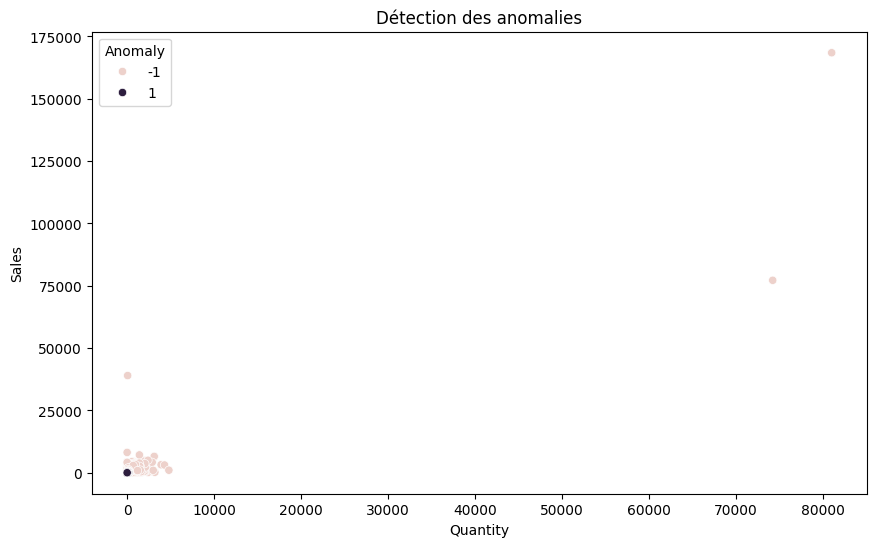

In [108]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Quantity',
    y='Sales',
    hue='Anomaly'
)
plt.title("Détection des anomalies")
plt.show()

In [109]:
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02,
    novelty=True
)

lof_model.fit(Xf_train_scaled)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [112]:
joblib.dump(iso, "model/anomalies_model.pkl")
joblib.dump(fraud_scaler, "model/fraud_scaler.pkl")

['model/fraud_scaler.pkl']

## IV. Architecture du système

Data (CSV / Base de données)

        ↓

Prétraitement

        ↓

Modèle ML

        ↓

API FastAPI

        ↓

Interface Streamlit

        ↓

Utilisateur

## V. Proposition de déploiement

Cloud Streamlit

Mettre le projet sur git en accès public

Proceder au deploiement

# VI. Demo

https://saleevaluate.streamlit.app